In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [171]:
sns.set_theme()

In [172]:
data = pd.read_csv("experiments/intel-experiments.csv")

In [173]:
data.sort_values(by="time", inplace=True)

In [174]:
data.head()

,threads,iterations,time
5,12,10,1.659751
10,11,10,1.714872
14,10,10,1.793992
15,9,10,1.957816
16,8,10,2.123469


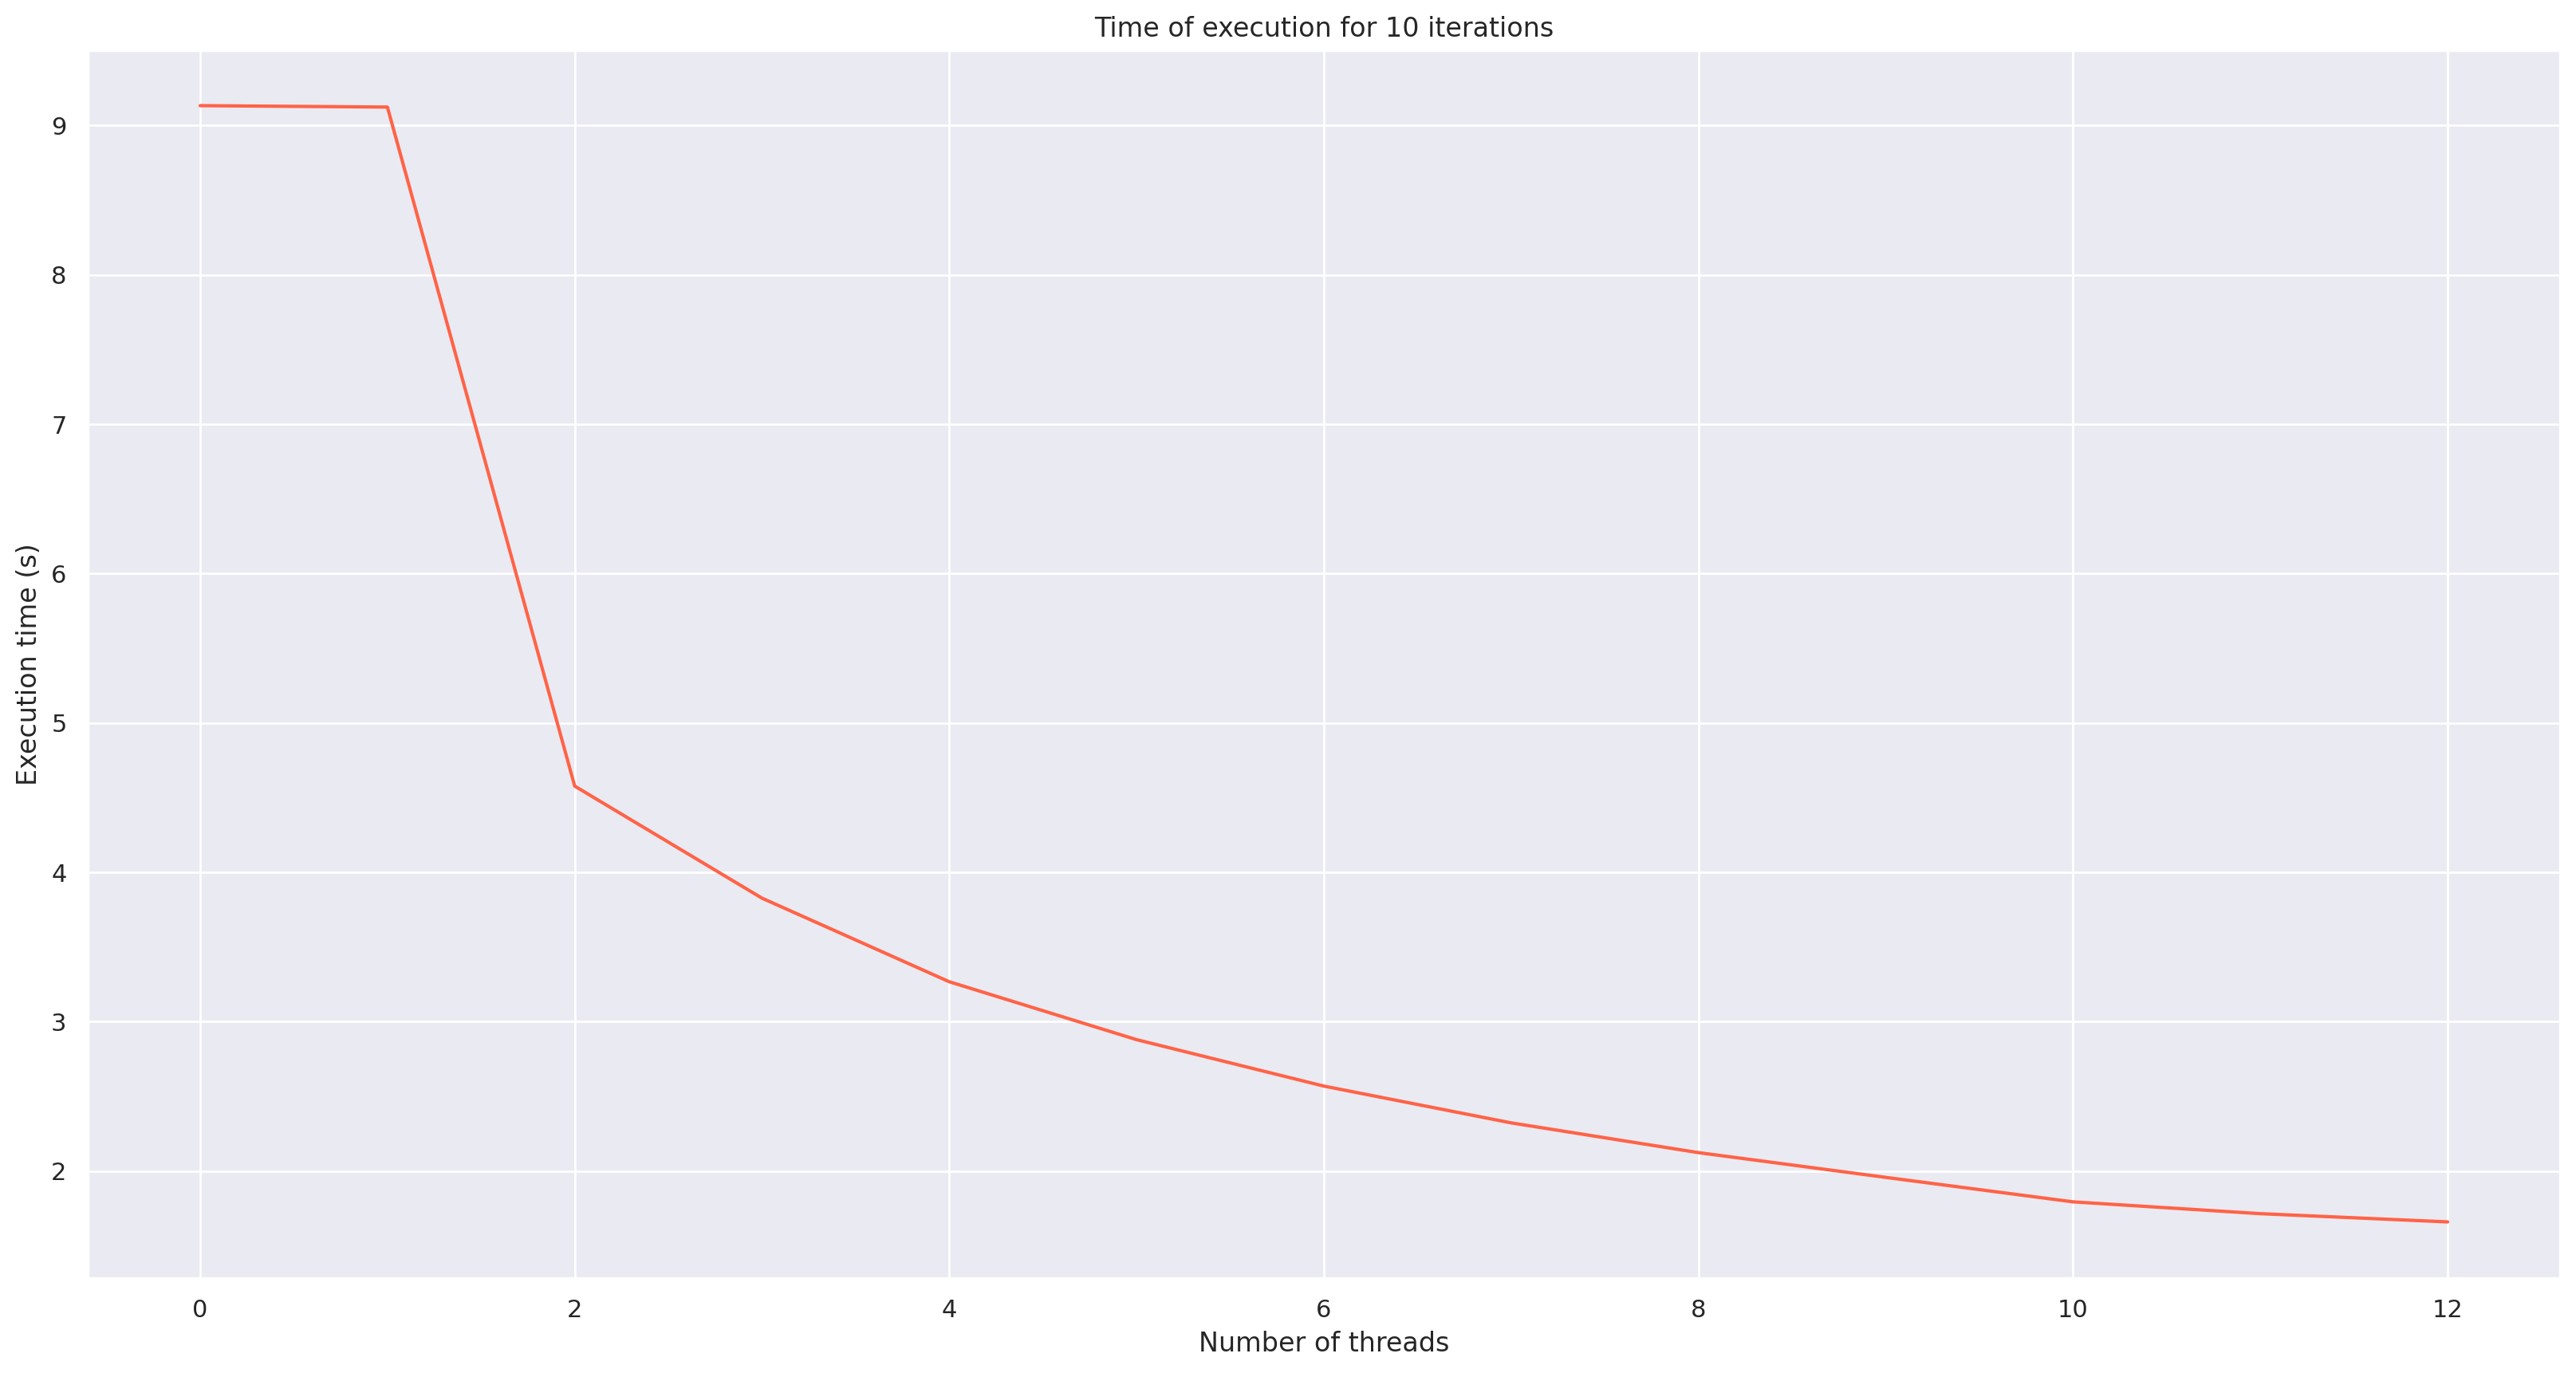

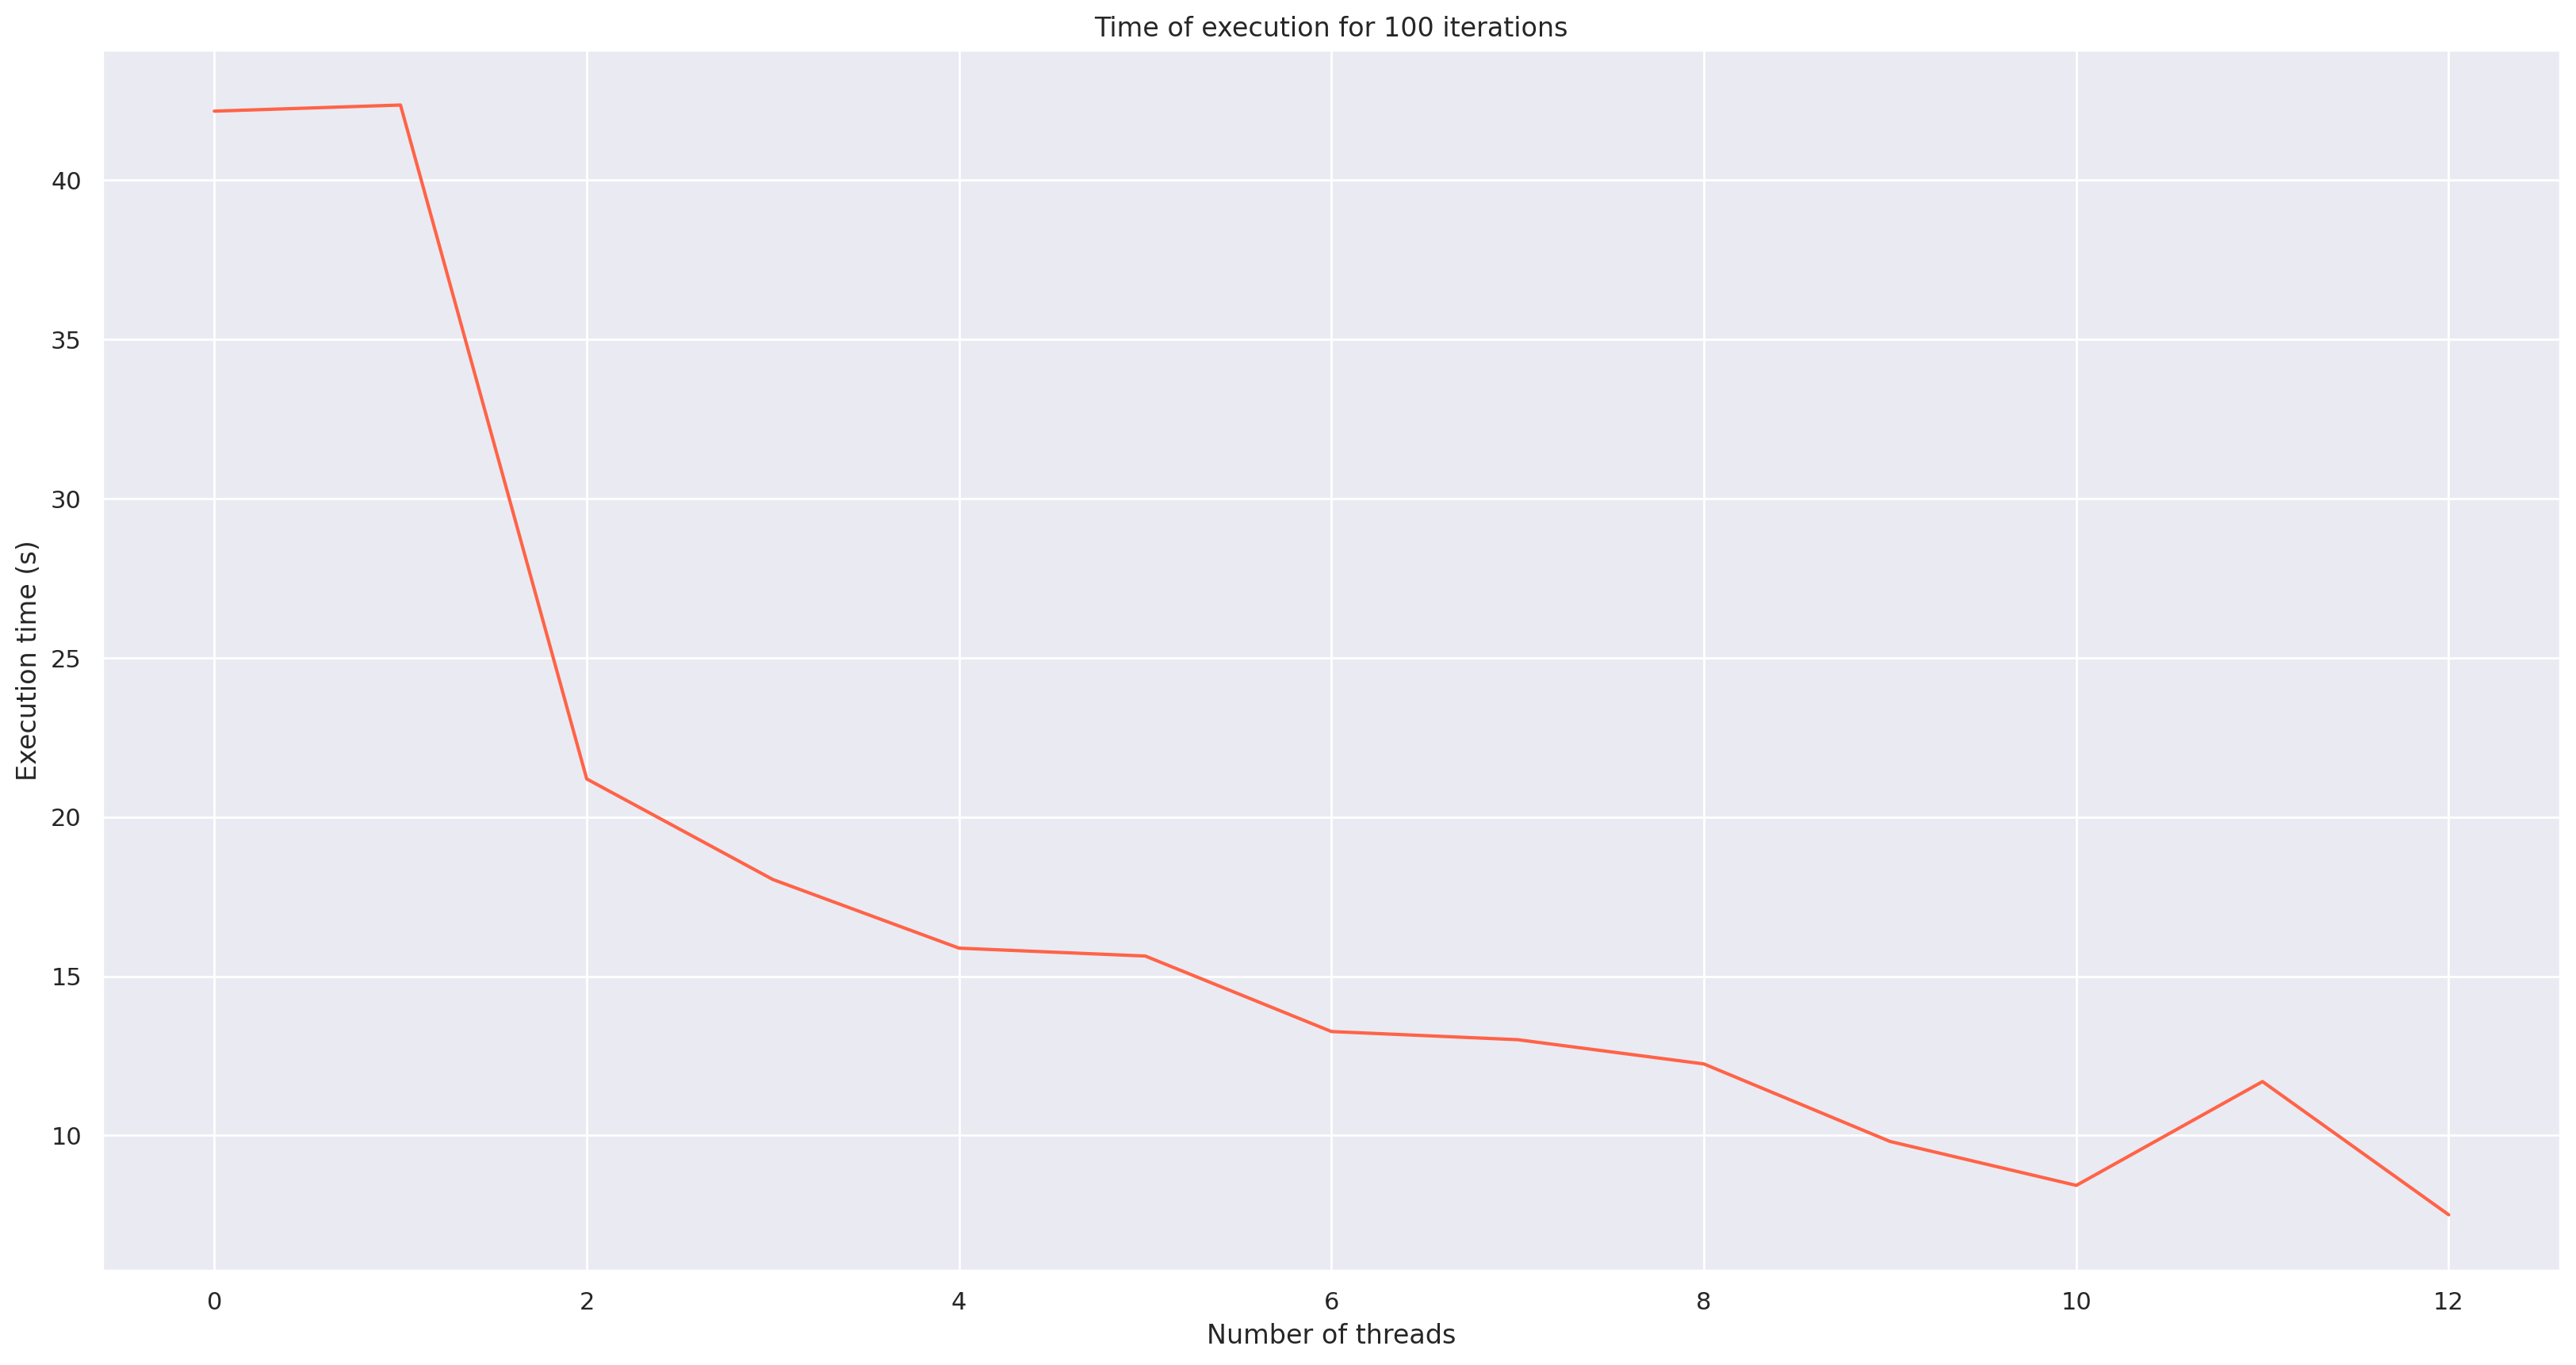

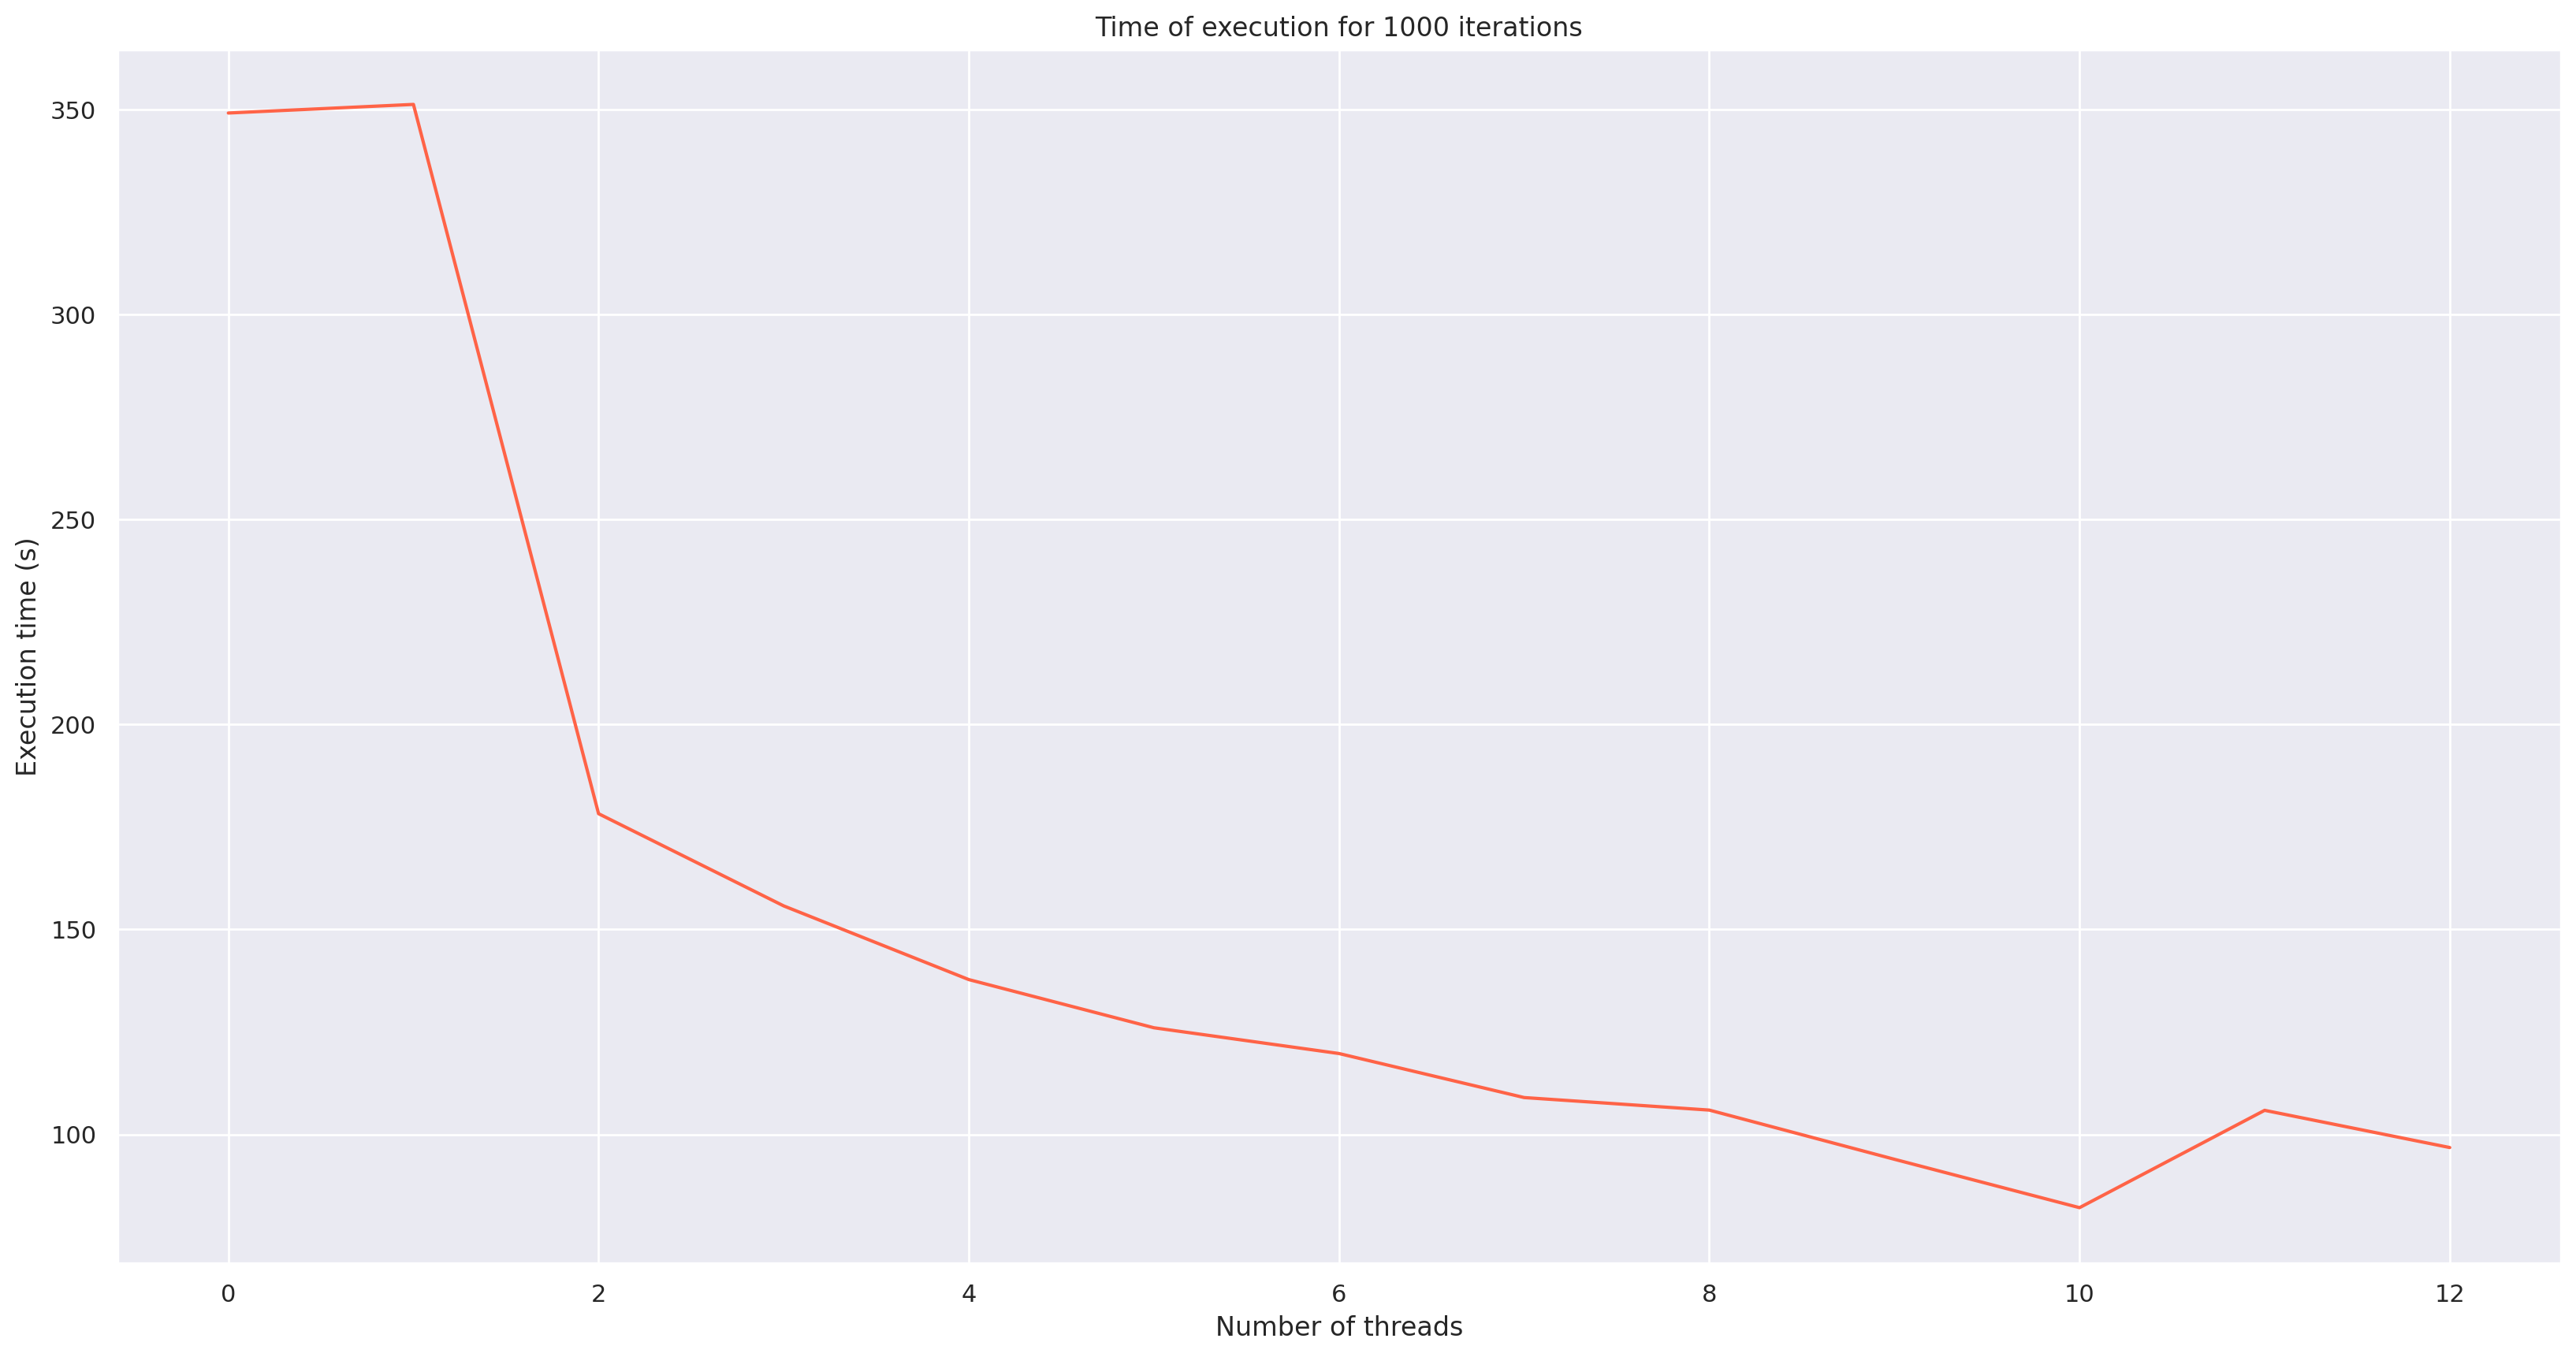

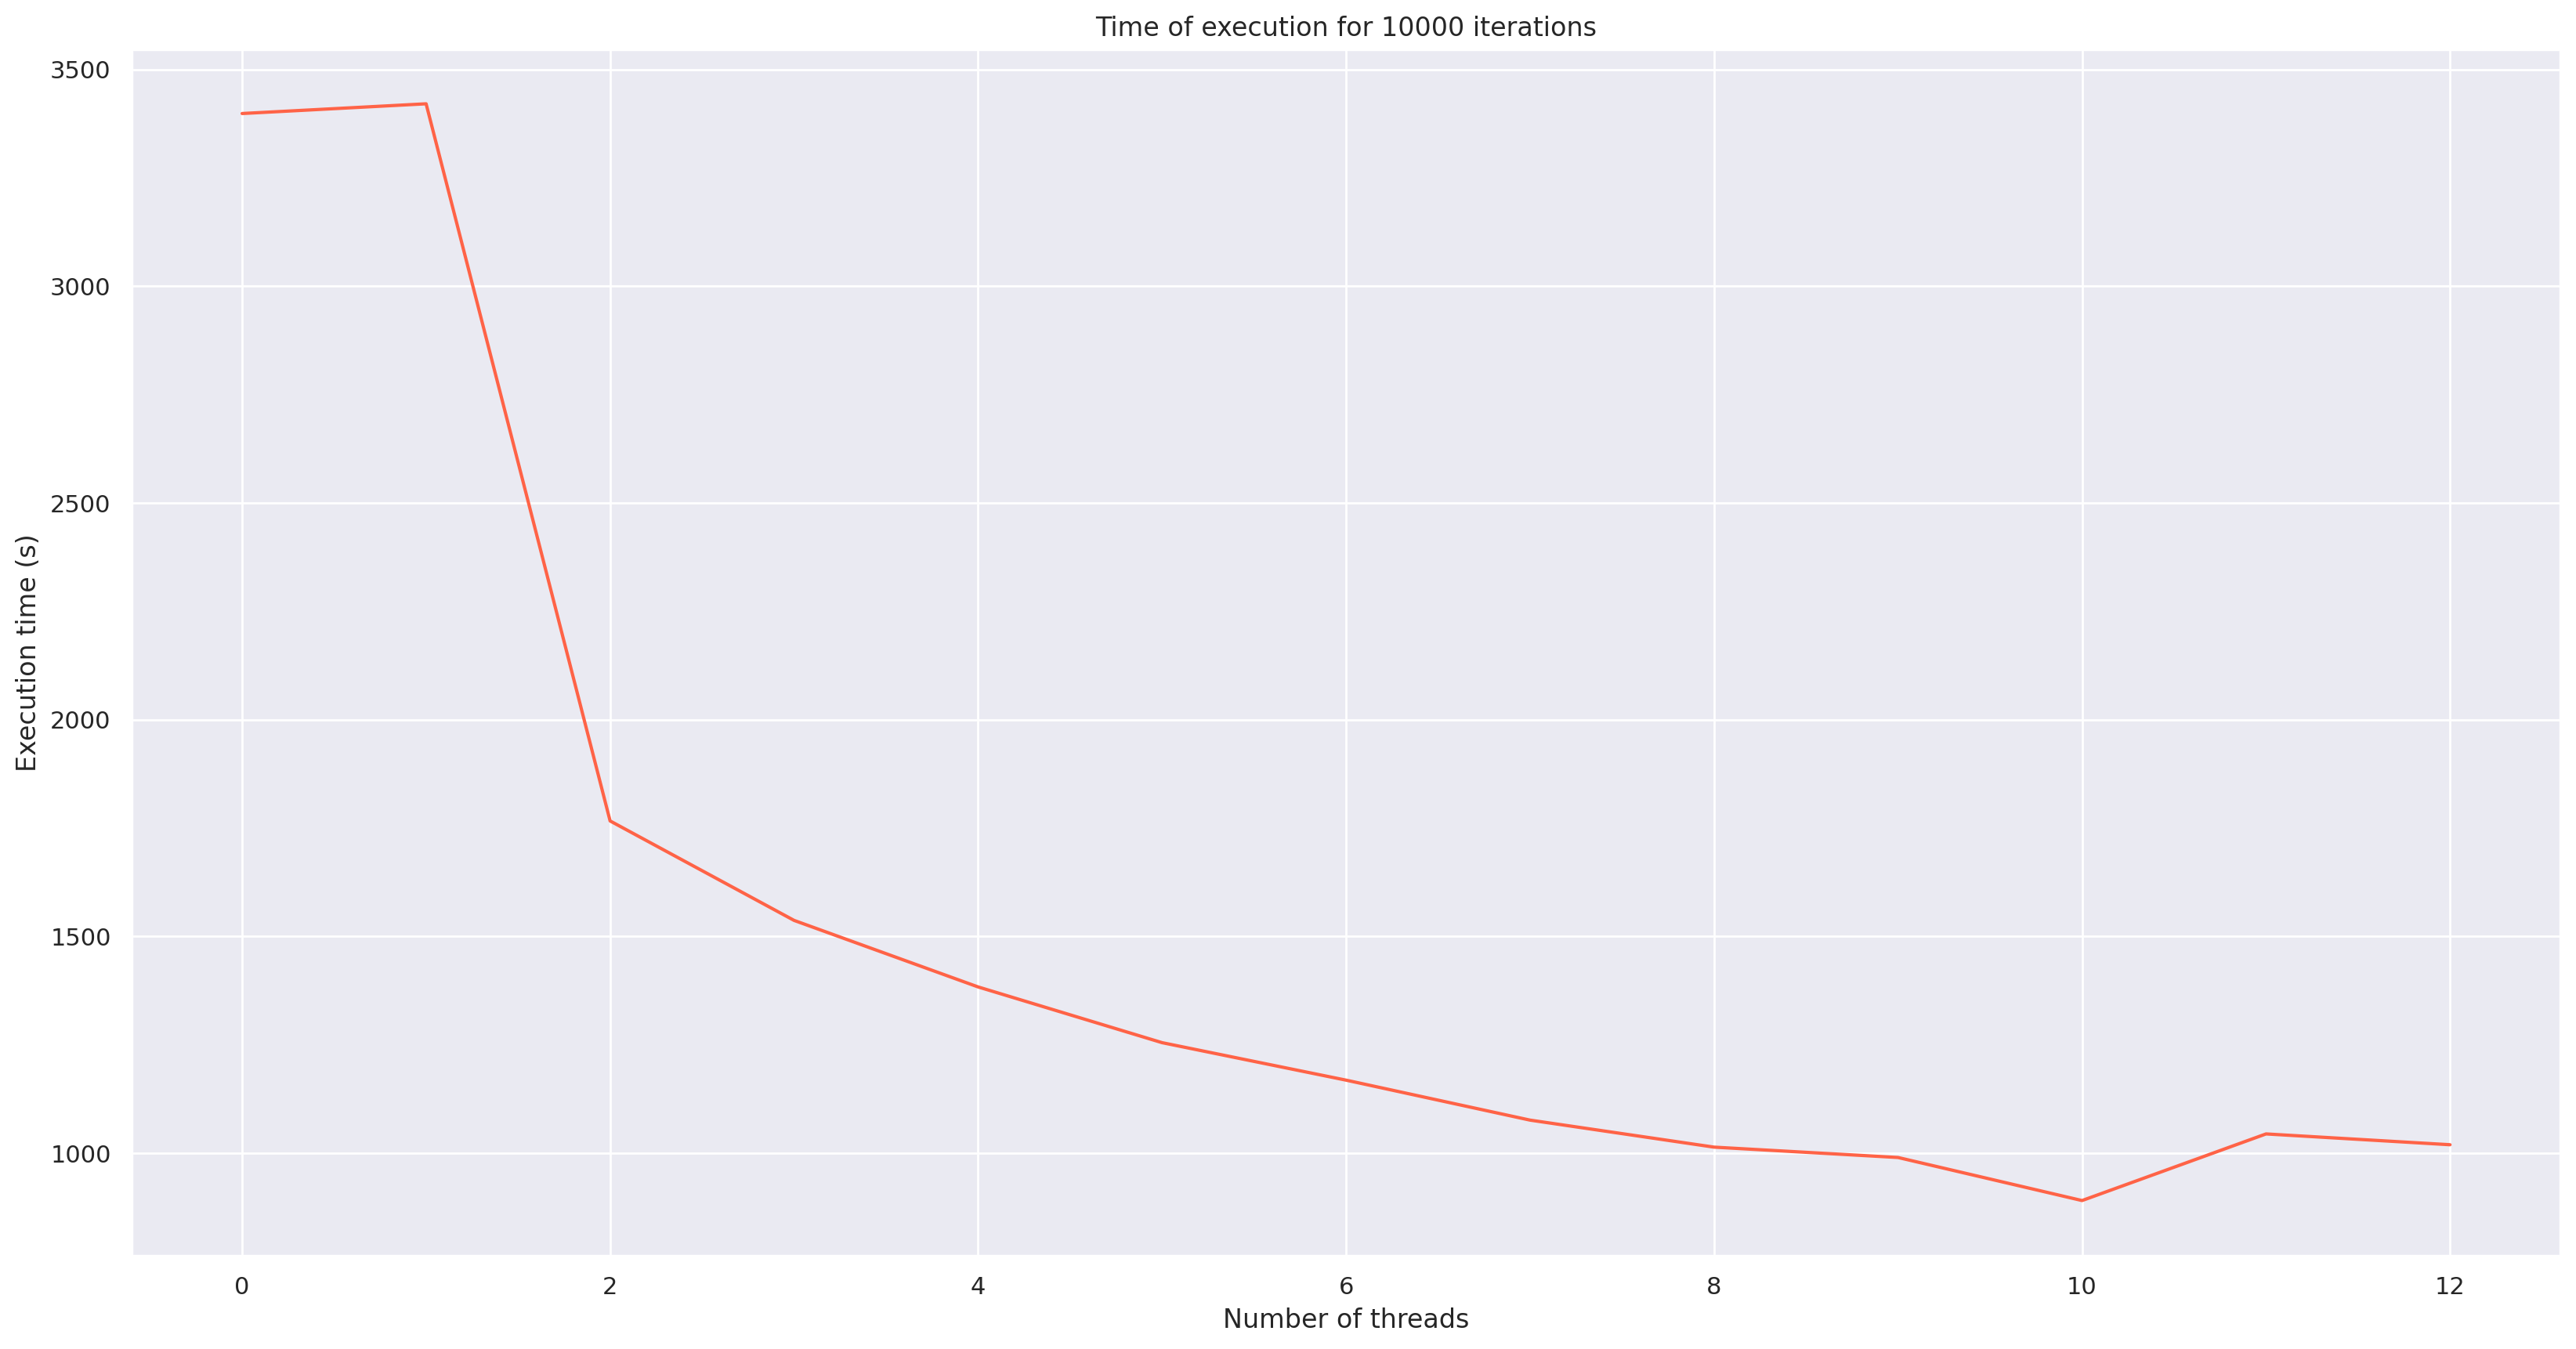

In [175]:
for number_of_iterations in (10, 100, 1000, 10000):
    plt.figure(figsize=(20, 10), dpi=200)
    chart = sns.lineplot(
        data[data["iterations"] == number_of_iterations],
        x="threads",
        y="time",
        color="tomato",
    )
    chart.set_ylabel("Execution time (s)")
    chart.set_xlabel("Number of threads")
    chart.set_title(f"Time of execution for {number_of_iterations} iterations")
    plt.savefig(
        "images/intel_time_per_threads_" + str(number_of_iterations) + "_iterations.png",
        bbox_inches="tight",
    )

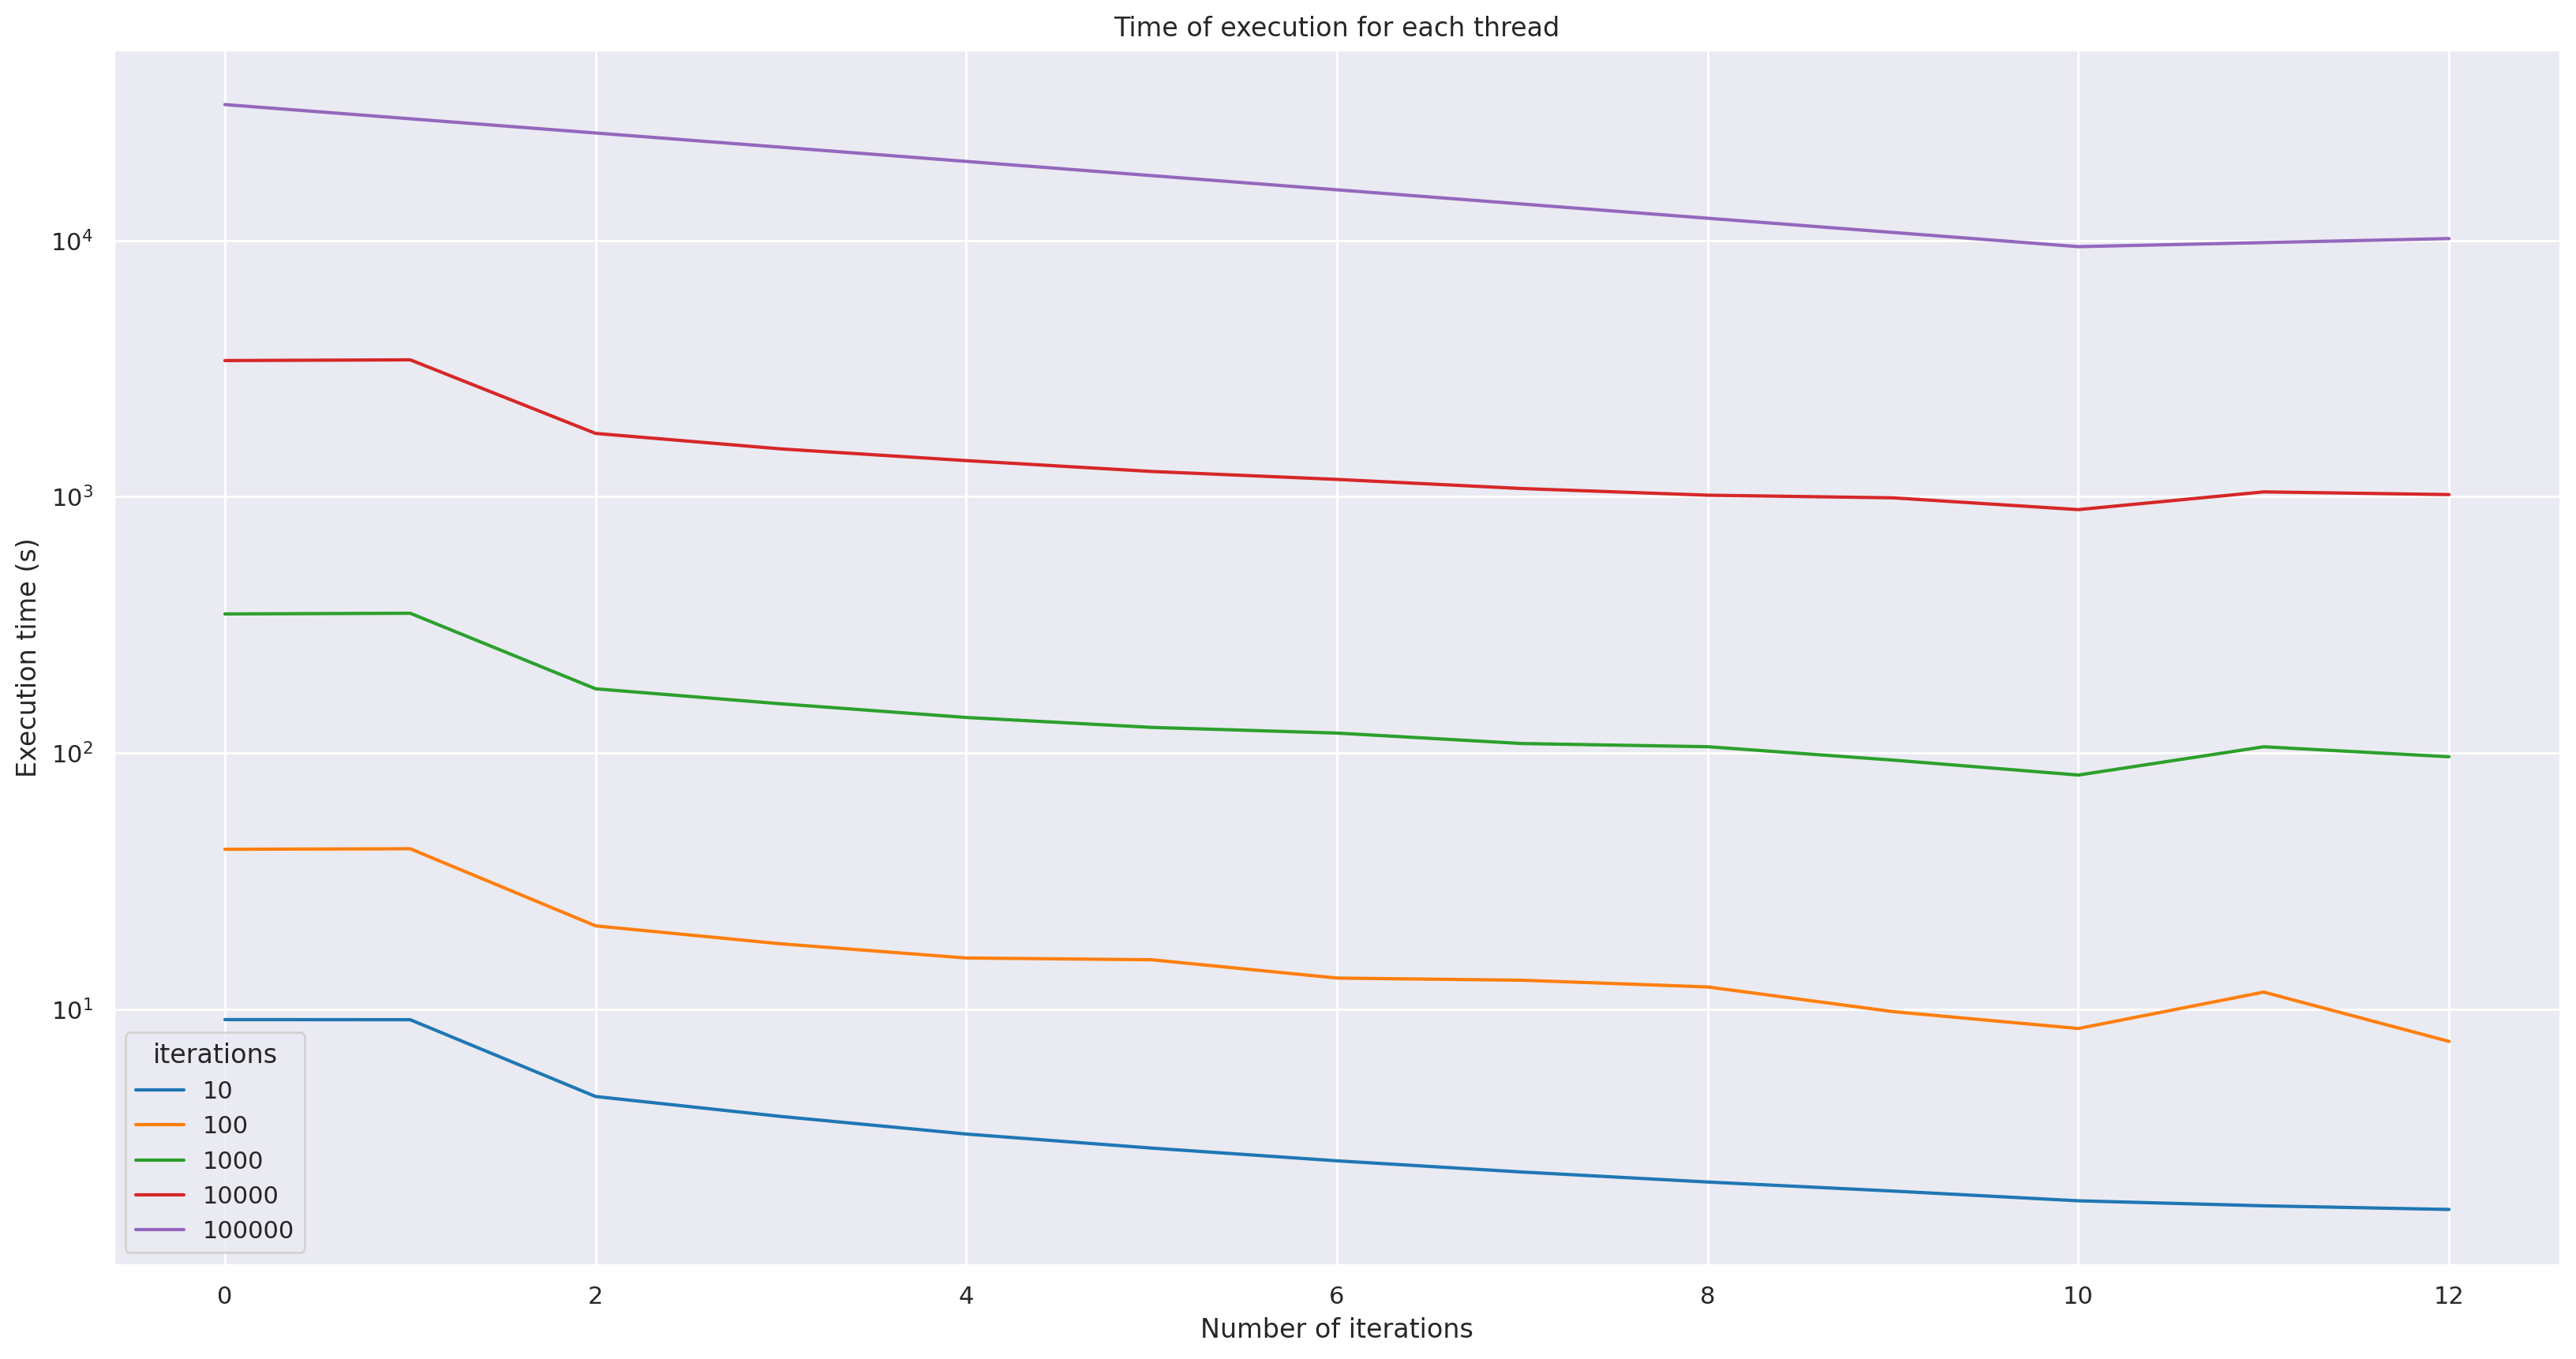

In [205]:
plt.figure(figsize=(20, 10), dpi=200)
chart = sns.lineplot(data, x="threads", y="time", hue="iterations", palette="tab10")
chart.set_ylabel("Execution time (s)")
chart.set_xlabel("Number of iterations")
chart.set_title("Time of execution for each thread")
chart.set_yscale("log")
plt.savefig("images/intel_time_per_threads_all_iterations.png", bbox_inches="tight")

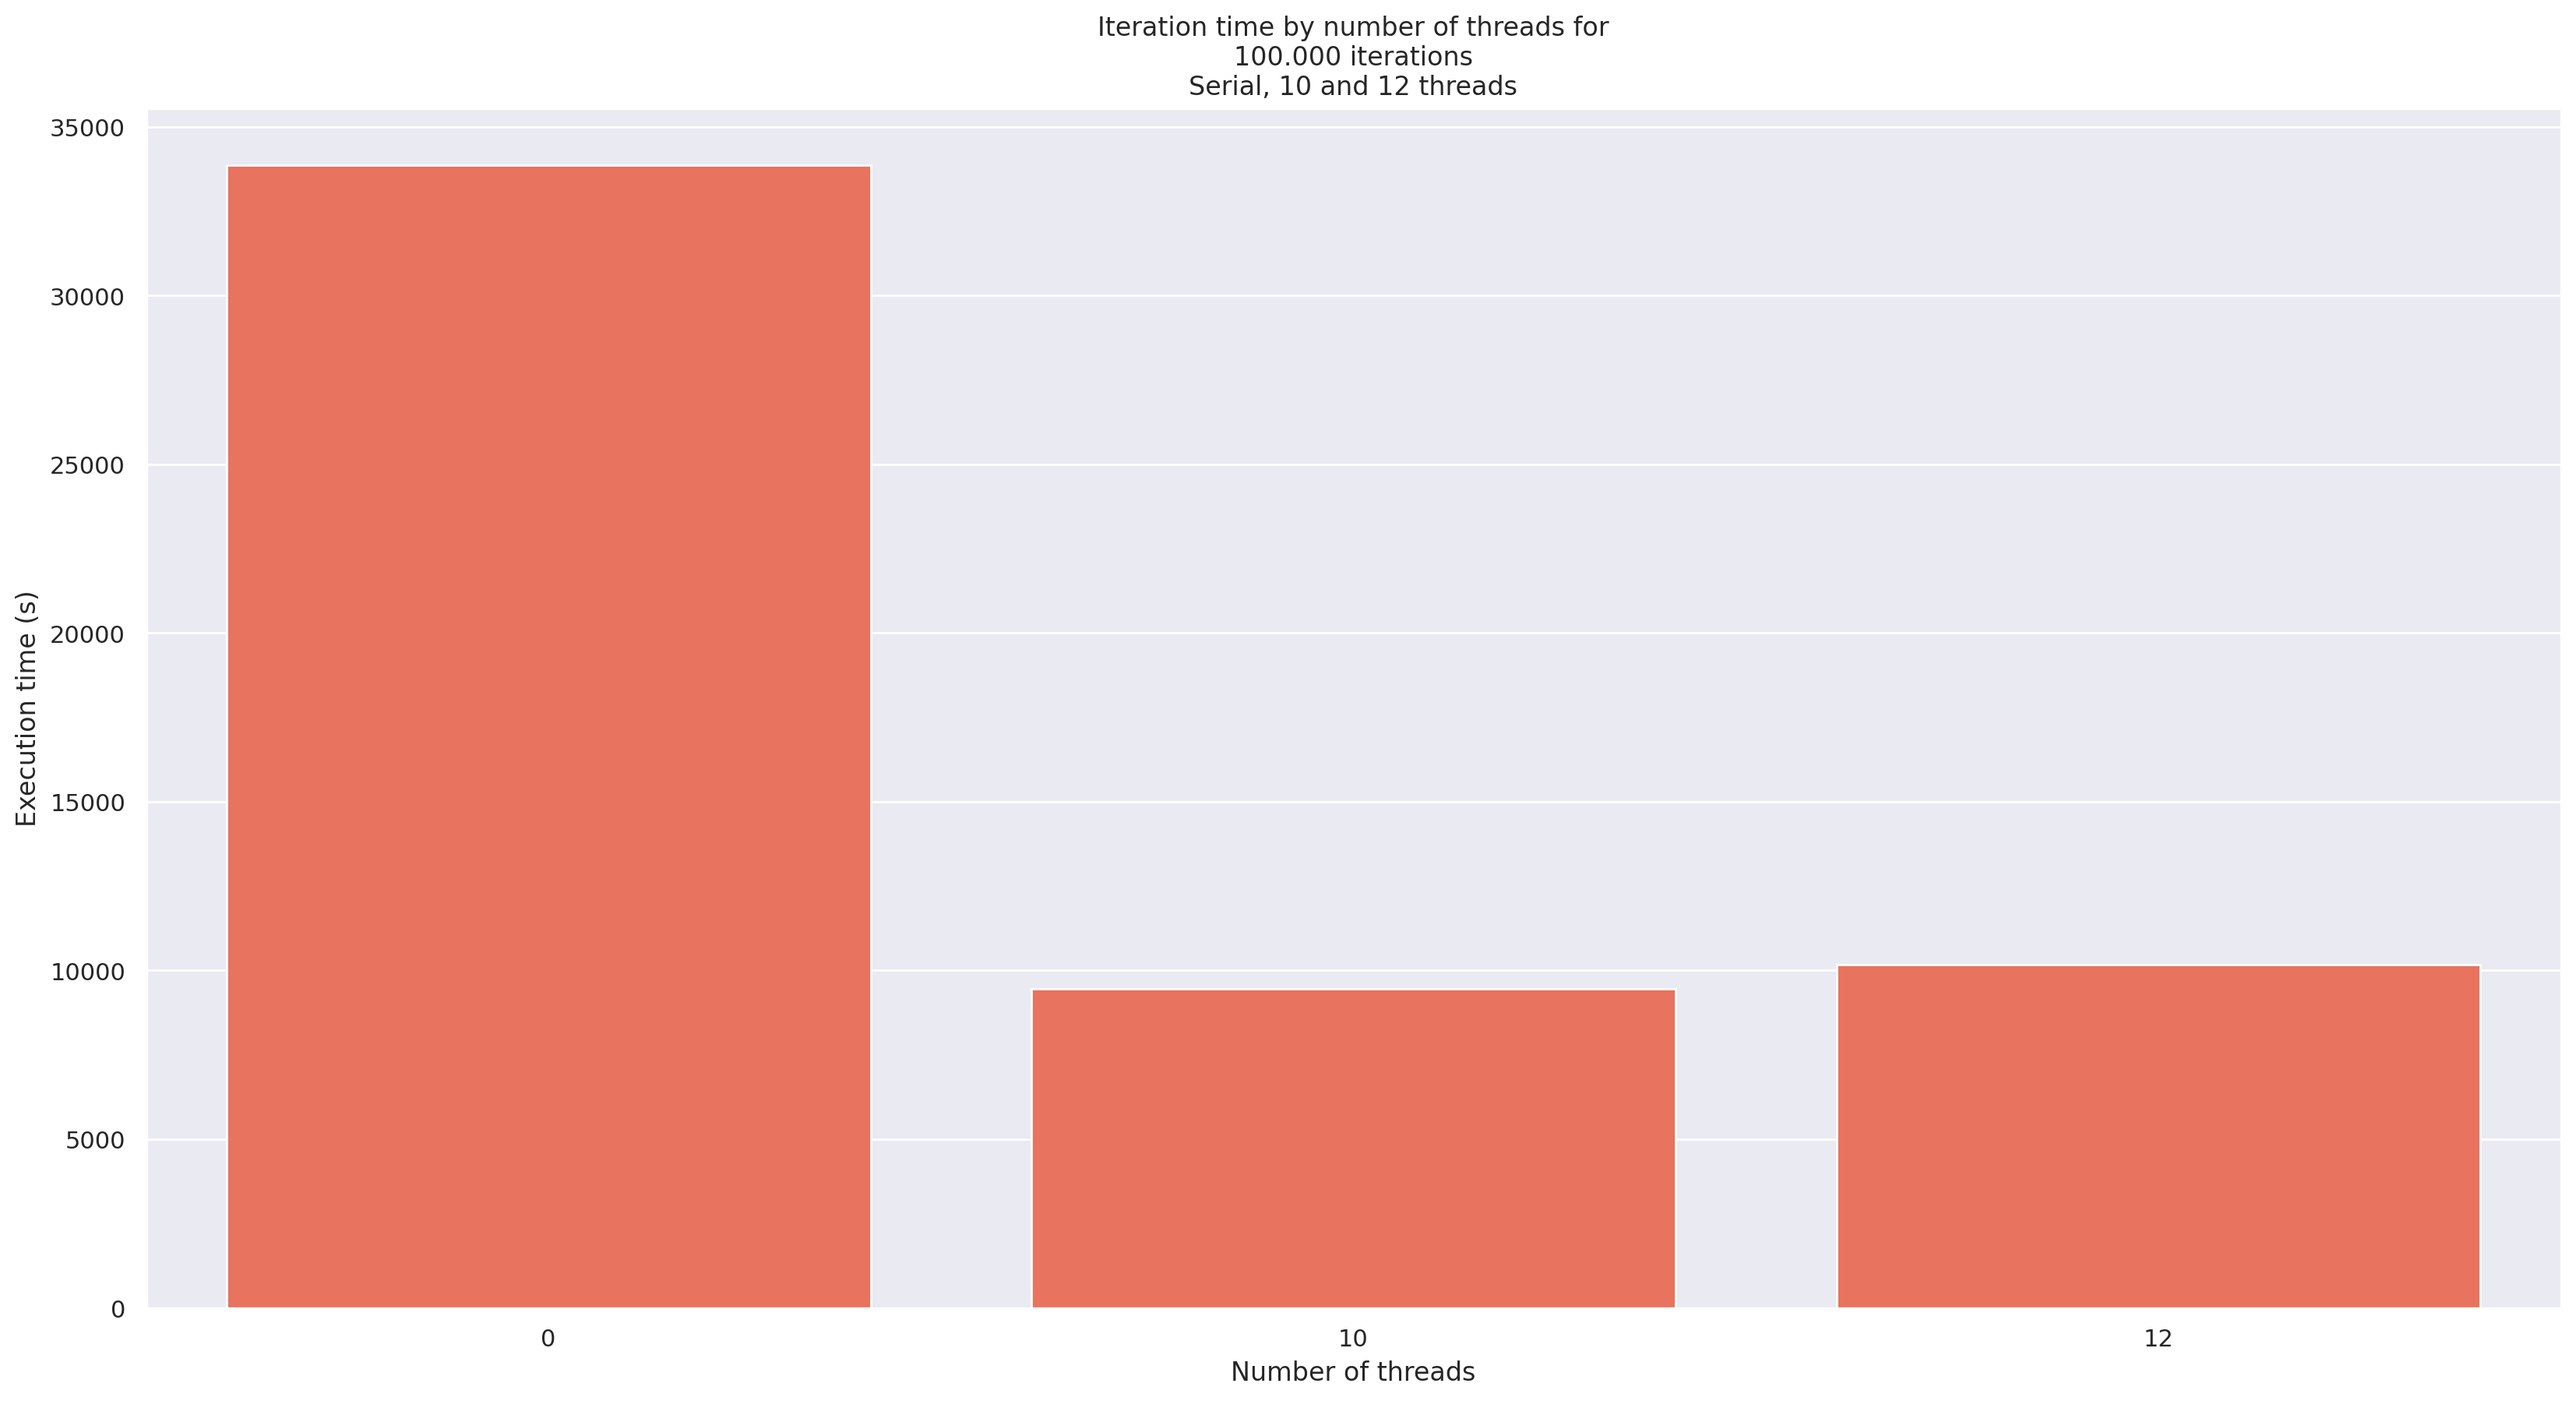

In [177]:
plt.figure(figsize=(20, 10), dpi=200)
one_hundred_iterations_chart = sns.barplot(
    data[data["iterations"] == 100000], x="threads", y="time", color="tomato"
)
one_hundred_iterations_chart.set_ylabel("Execution time (s)")
one_hundred_iterations_chart.set_xlabel("Number of threads")
one_hundred_iterations_chart.set_title(
    "Iteration time by number of threads for\n100.000 iterations\nSerial, 10 and 12 threads"
)
plt.savefig("images/intel_100000_iterations.png", bbox_inches="tight")

In [178]:
executionStatic = pd.read_csv('experiments/static-scheduling.csv')

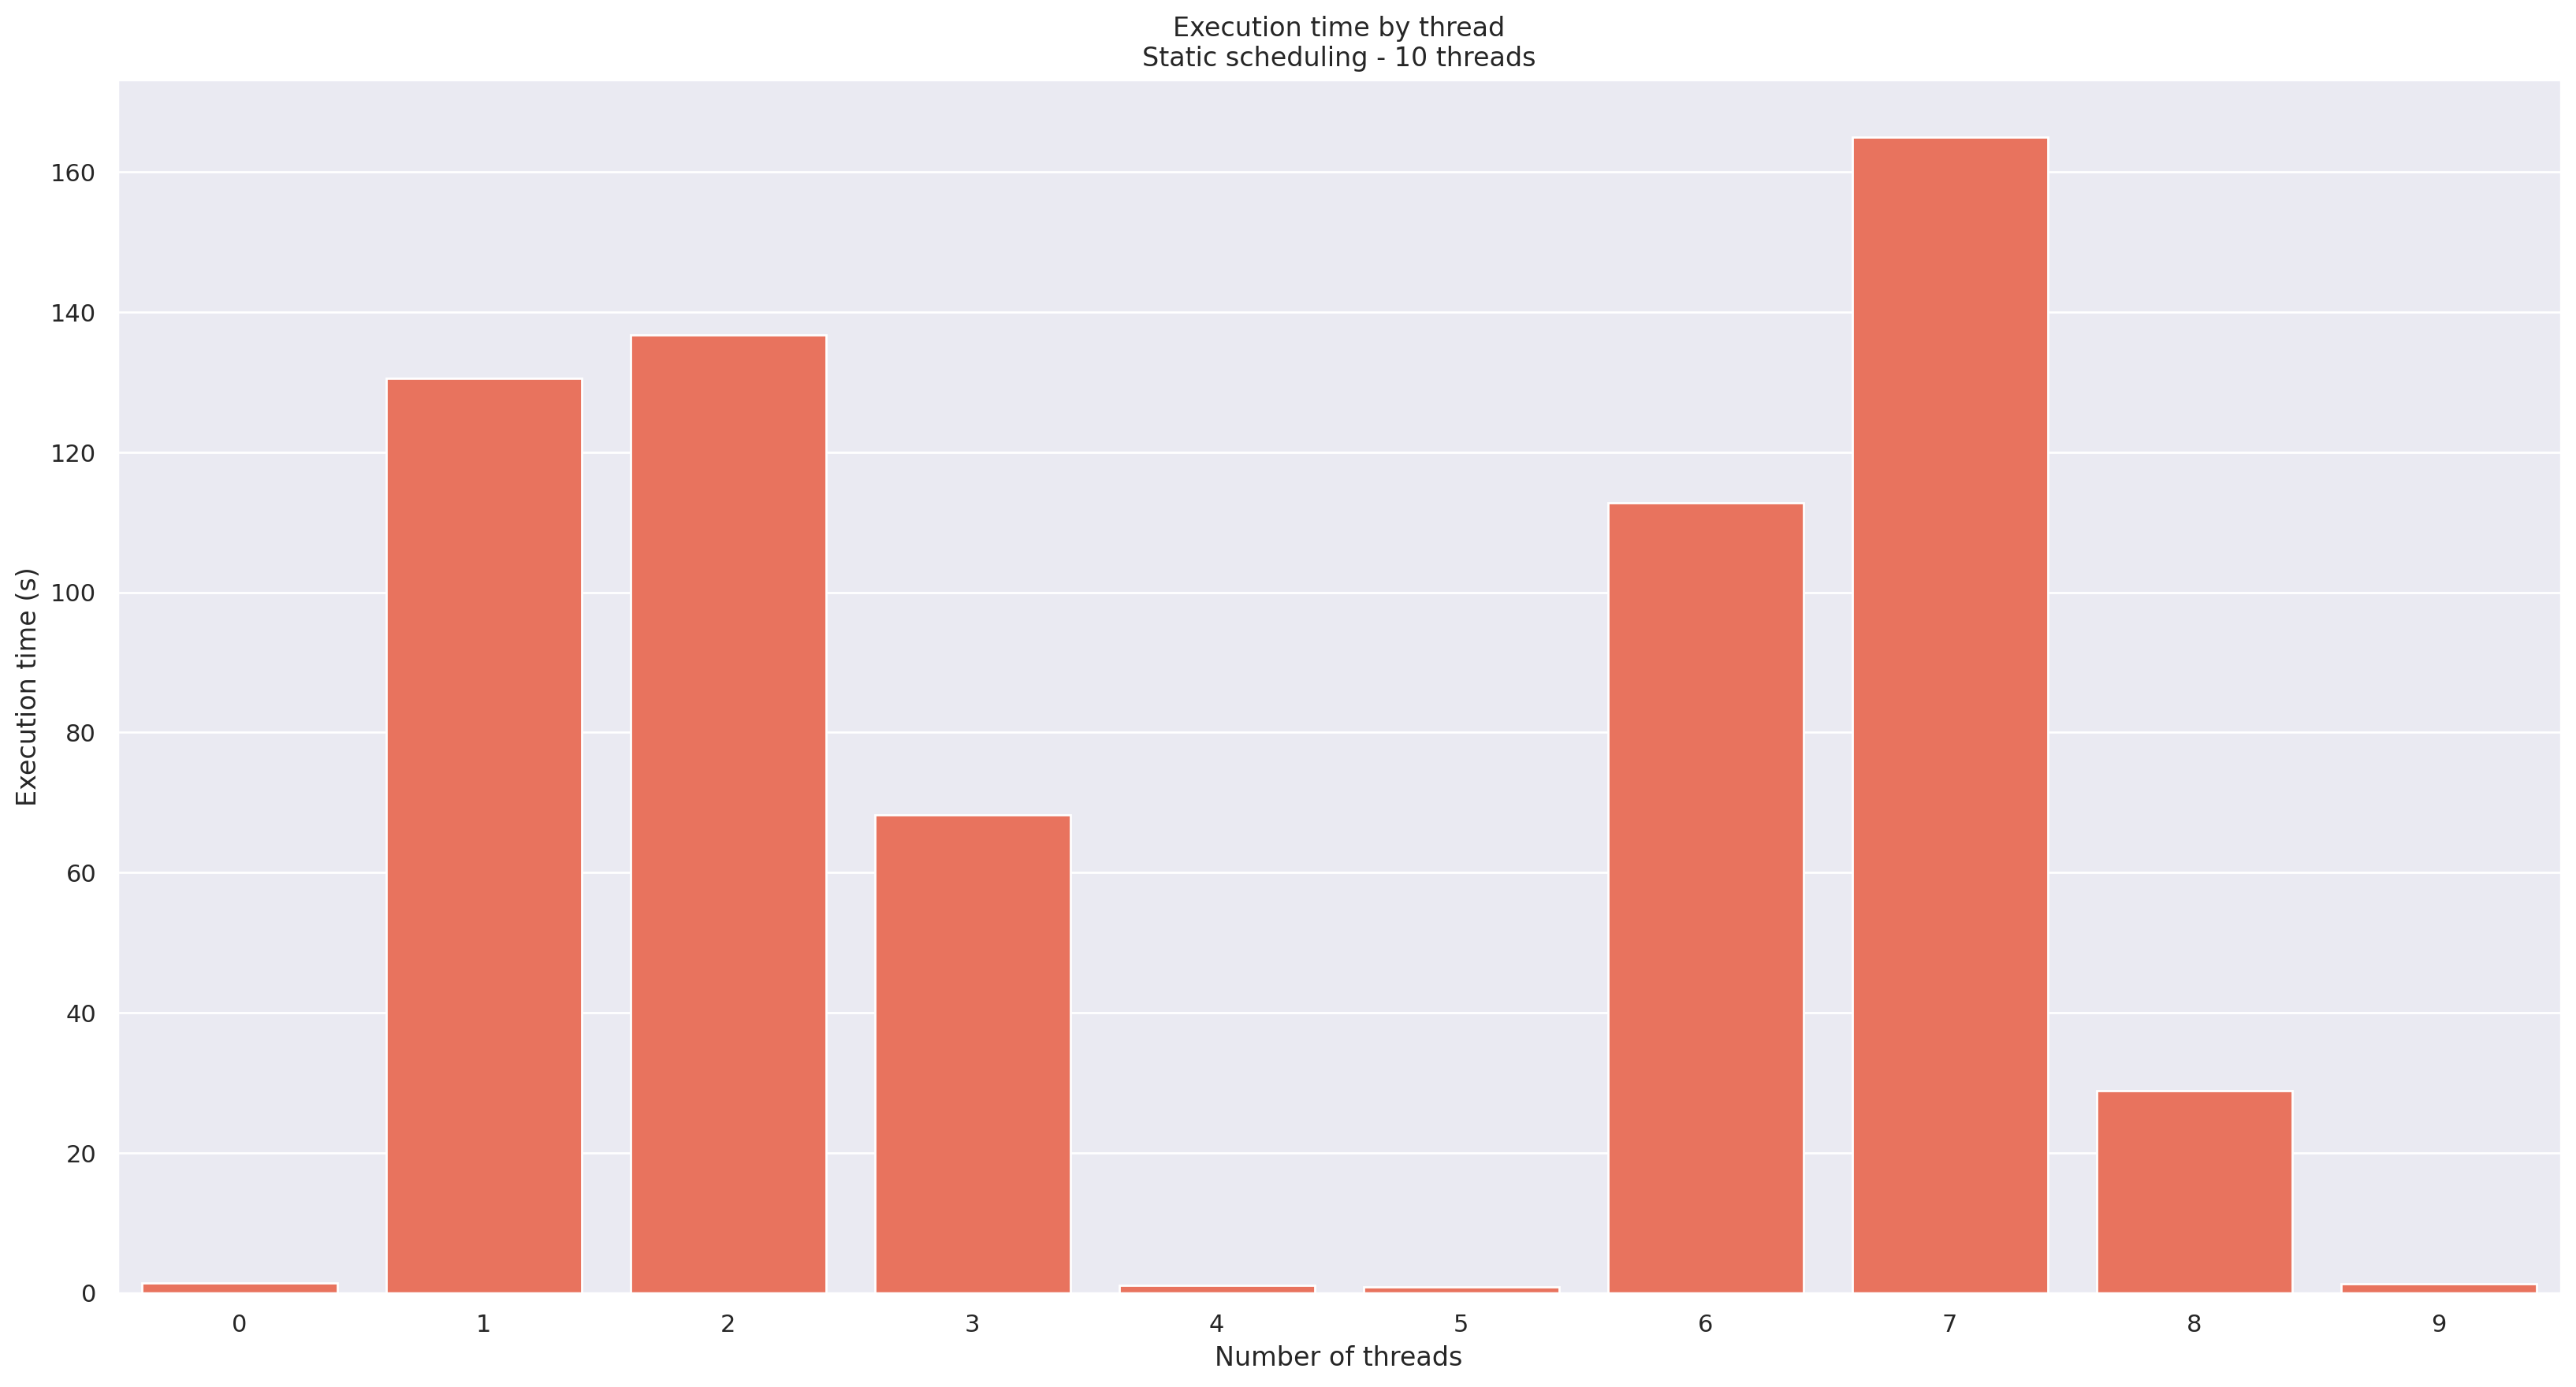

In [179]:
plt.figure(figsize=(20, 10), dpi=200)
staticScheduling = sns.barplot(executionStatic, x="threadId", y="time", color="tomato")
staticScheduling.set_ylabel("Execution time (s)")
staticScheduling.set_xlabel("Number of threads")
staticScheduling.set_title("Execution time by thread\nStatic scheduling - 10 threads")
plt.savefig('images/intel_static_scheduling.png', bbox_inches='tight')

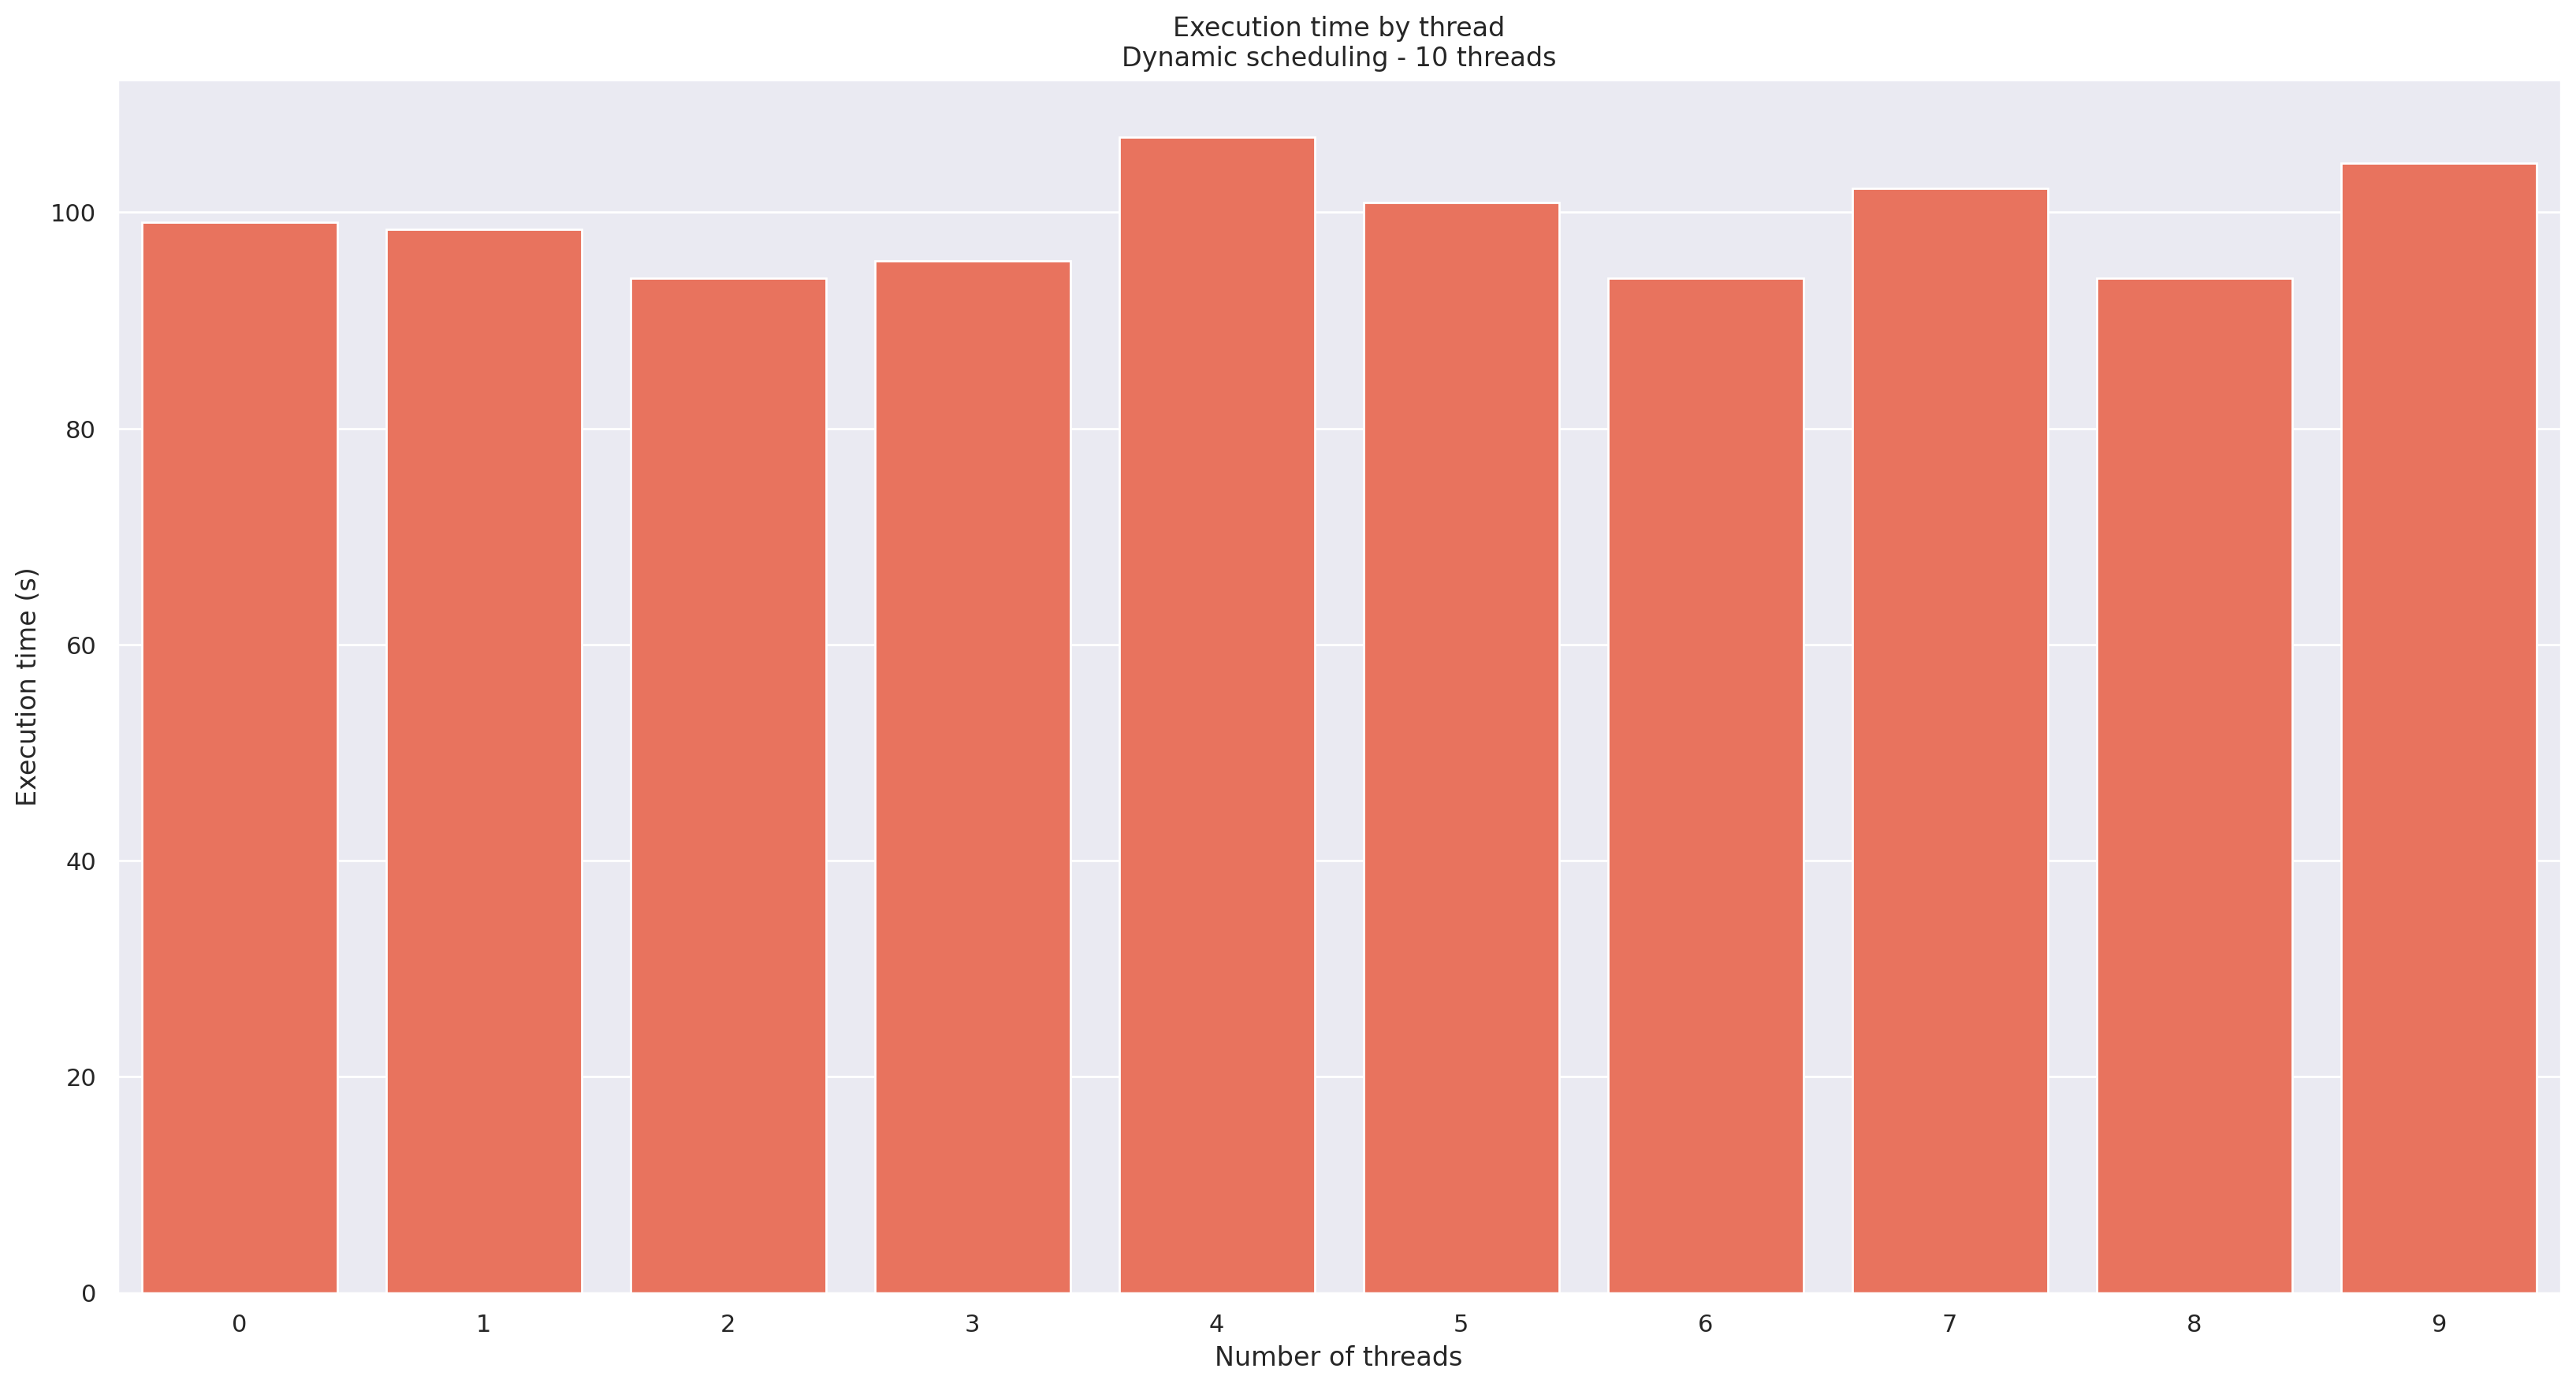

In [180]:
executionDynamic = pd.read_csv("experiments/dynamic-scheduling.csv")
plt.figure(figsize=(20, 10), dpi=200)
dynamicScheduling = sns.barplot(
    executionDynamic, x="threadId", y="time", color="tomato"
)
dynamicScheduling.set_ylabel("Execution time (s)")
dynamicScheduling.set_xlabel("Number of threads")
dynamicScheduling.set_title("Execution time by thread\nDynamic scheduling - 10 threads")
plt.savefig("images/intel_dynamic_scheduling.png", bbox_inches="tight")

In [181]:
def calculate_speedup(row):
    first_execution_time = row.loc[row["threads"] == 0, ["time"]].time.item()
    row["speed_up"] = first_execution_time / row["time"]
    return row

In [197]:
grouped_by_iterations = data.groupby("iterations")
grouped_by_iterations = grouped_by_iterations.apply(
    calculate_speedup, include_groups=False
).reset_index()
grouped_by_iterations.drop(columns=["level_1"], inplace=True)

In [199]:
grouped_by_iterations.head()

,iterations,threads,time,speed_up
0,10,12,1.659751,5.502192
1,10,11,1.714872,5.325336
2,10,10,1.793992,5.090474
3,10,9,1.957816,4.664519
4,10,8,2.123469,4.300637


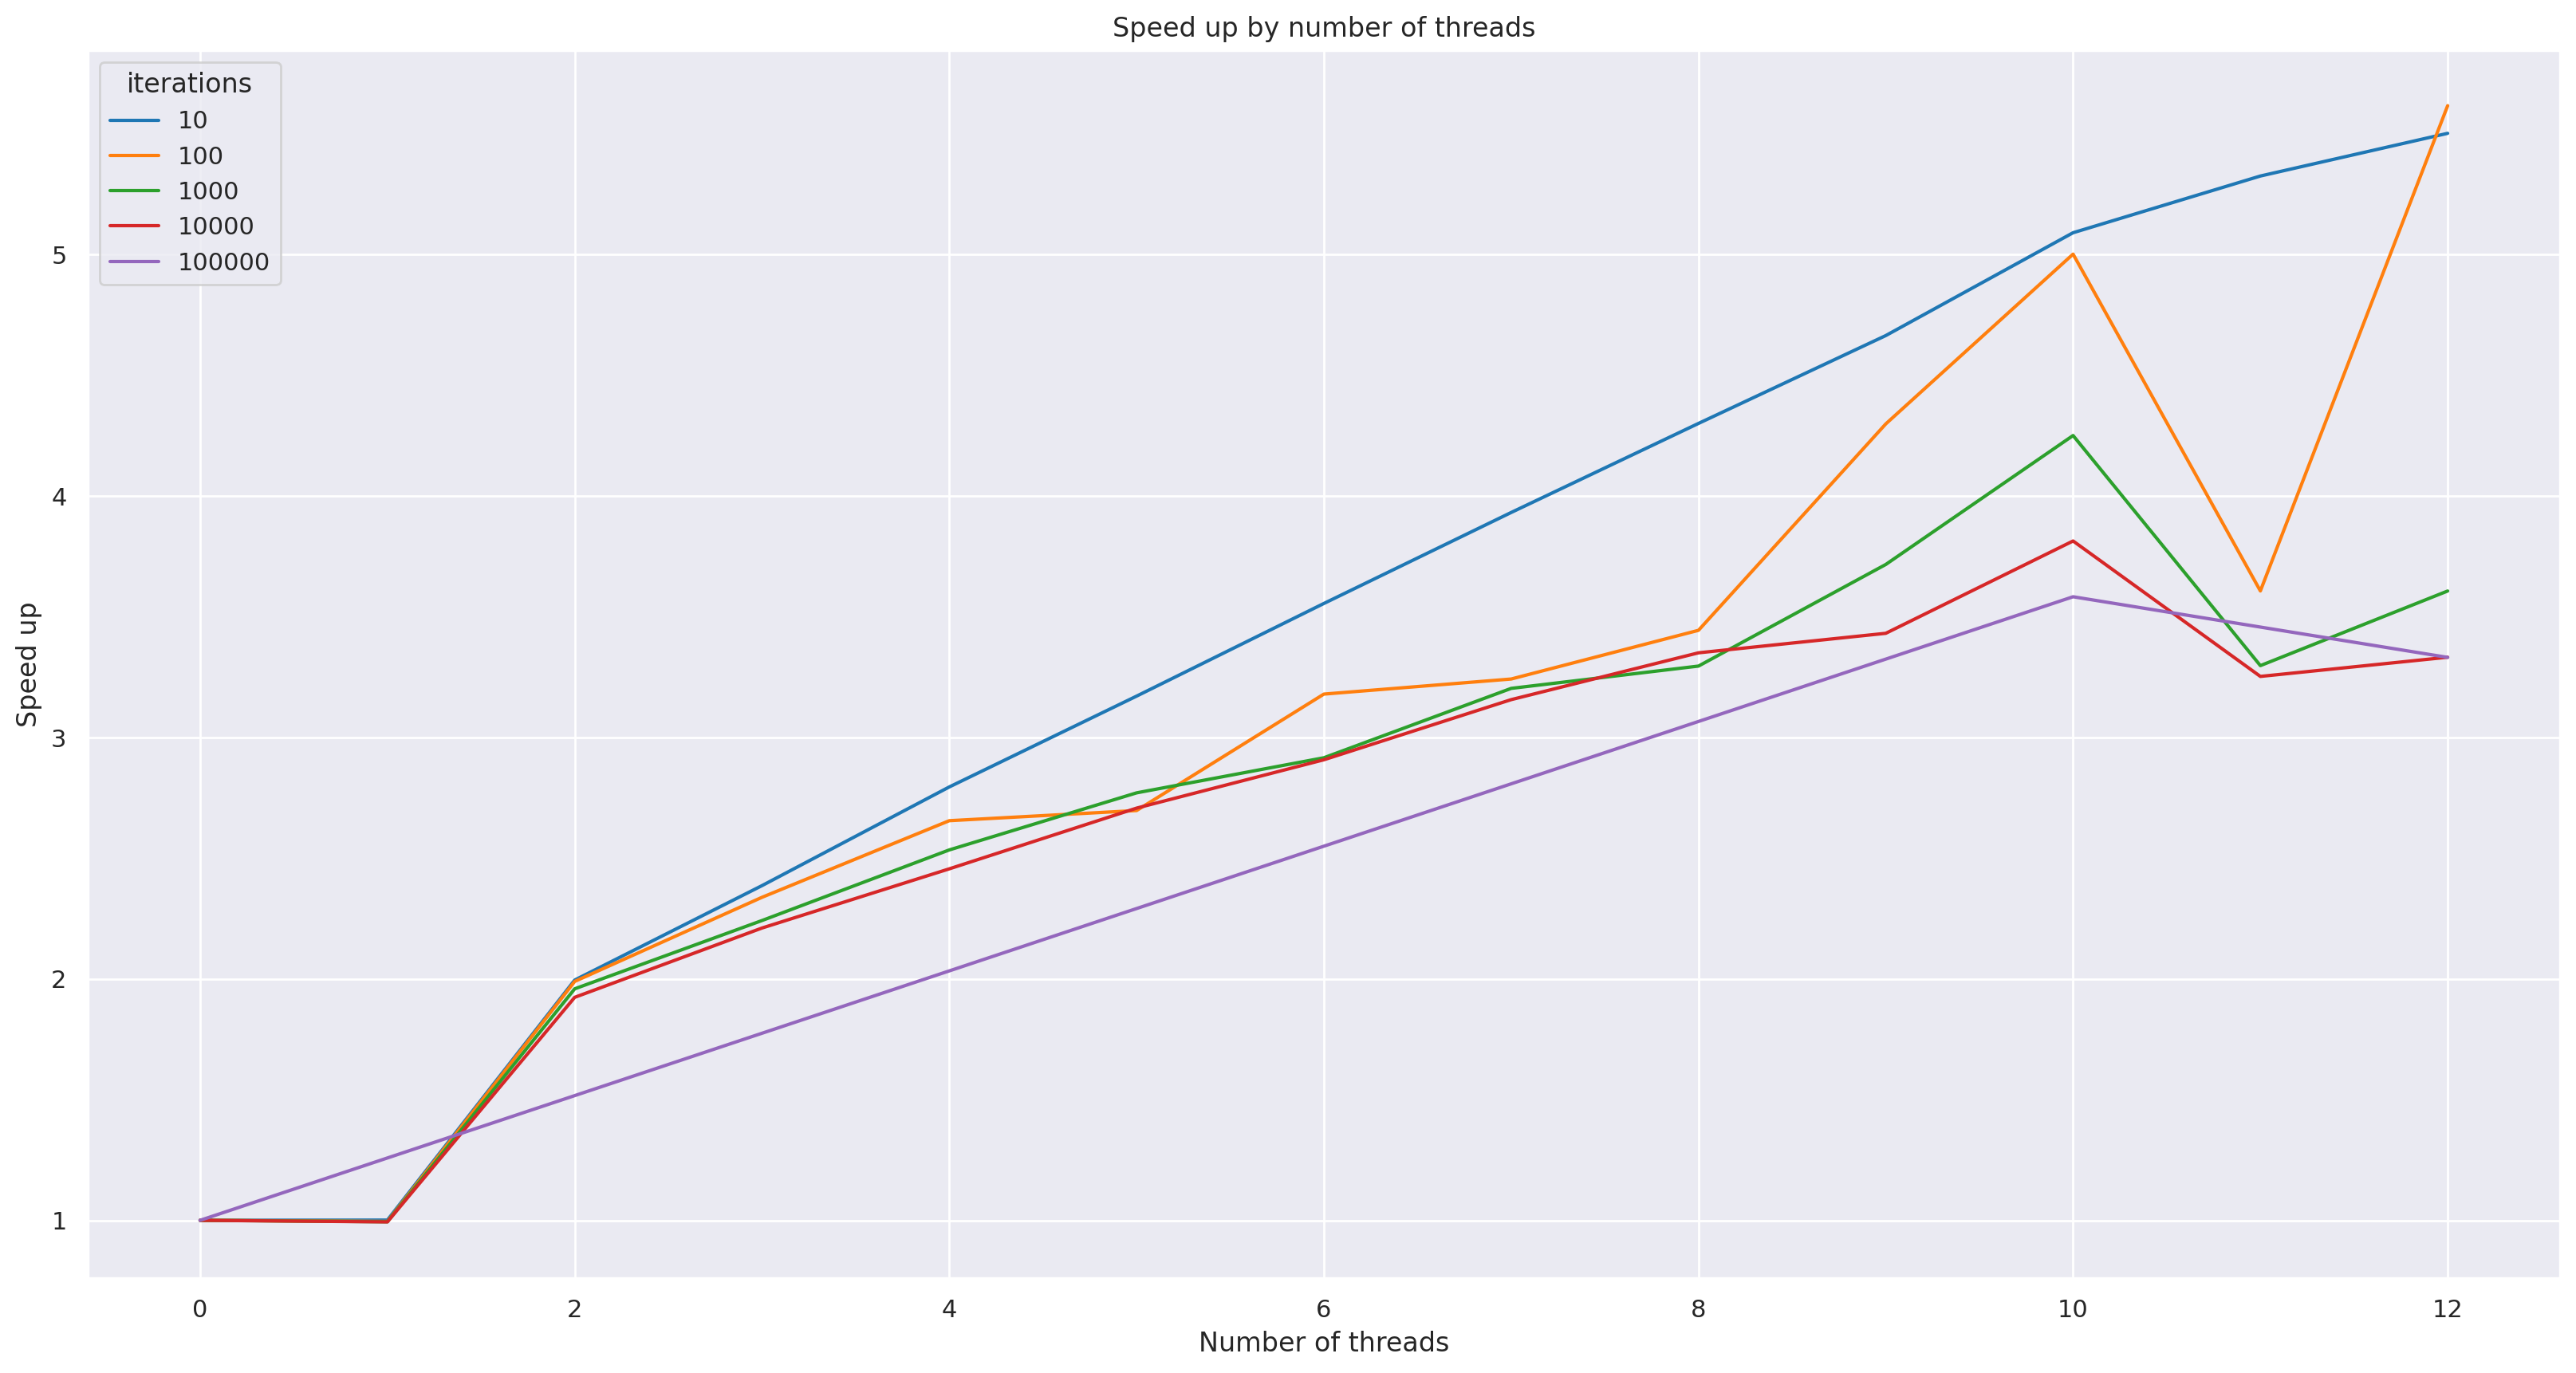

In [203]:
plt.figure(figsize=(20, 10), dpi=200)
chart = sns.lineplot(
    grouped_by_iterations,
    x="threads",
    y="speed_up",
    hue="iterations",
    palette="tab10",
)
chart.set_ylabel("Speed up")
chart.set_xlabel("Number of threads")
chart.set_title("Speed up by number of threads")
plt.savefig("images/intel_speed_up.png", bbox_inches="tight")